In [ ]:
import pandas as pd
import numpy as np
# Loading the dataset
df=pd.read_csv('/content/brain_stroke.csv')

In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


In [ ]:
# Checking number of missing values in each column
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,4.00,0,0,No,children,Urban,94.27,14.0,Unknown,0
1,Female,0.08,0,0,No,children,Urban,139.67,14.1,Unknown,0
2,Male,0.56,0,0,No,children,Urban,98.23,14.1,Unknown,0
3,Female,3.00,0,0,No,children,Rural,131.81,14.1,Unknown,0
4,Female,8.00,0,0,No,children,Rural,87.92,14.1,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,14.00,0,0,No,Private,Urban,79.36,48.8,never smoked,0
4977,Female,53.00,0,0,Yes,Govt_job,Rural,81.36,48.8,never smoked,0
4978,Female,37.00,0,0,Yes,Private,Rural,94.77,48.9,Unknown,0
4979,Female,50.00,0,0,Yes,Govt_job,Urban,89.95,48.9,formerly smoked,0


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()

In [ ]:
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [ ]:
X = df.drop('stroke', axis=1)
y = le.fit_transform(df['stroke'])

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()

cat_cols = ["gender","ever_married","work_type",
            "Residence_type","smoking_status"]

# Encode categorical features in X before splitting
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Now split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Now scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Correlation matrix
corr=df.corr()
corr

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
gender,1.000000,-0.026538,0.021485,0.086476,-0.028971,0.065784,-0.004301,0.055796,-0.012093,-0.062666,0.008870
age,-0.026538,1.000000,0.278120,0.264852,0.677137,-0.415935,0.017155,0.236763,0.373703,0.265623,0.246478
hypertension,0.021485,0.278120,1.000000,0.111974,0.164534,-0.061618,-0.004755,0.170028,0.158762,0.110045,0.131965
heart_disease,0.086476,0.264852,0.111974,1.000000,0.114765,-0.036943,0.002125,0.166847,0.060926,0.048093,0.134610
ever_married,-0.028971,0.677137,0.164534,0.114765,1.000000,-0.406439,0.008191,0.150724,0.371690,0.262384,0.108398
work_type,0.065784,-0.415935,-0.061618,-0.036943,-0.406439,1.000000,-0.003524,-0.059658,-0.382418,-0.356738,-0.041835
Residence_type,-0.004301,0.017155,-0.004755,0.002125,0.008191,-0.003524,1.000000,0.001346,0.013185,0.010209,0.016494
avg_glucose_level,0.055796,0.236763,0.170028,0.166847,0.150724,-0.059658,0.001346,1.000000,0.186348,0.064089,0.133227
bmi,-0.012093,0.373703,0.158762,0.060926,0.371690,-0.382418,0.013185,0.186348,1.000000,0.243111,0.056926
smoking_status,-0.062666,0.265623,0.110045,0.048093,0.262384,-0.356738,0.010209,0.064089,0.243111,1.000000,0.027463


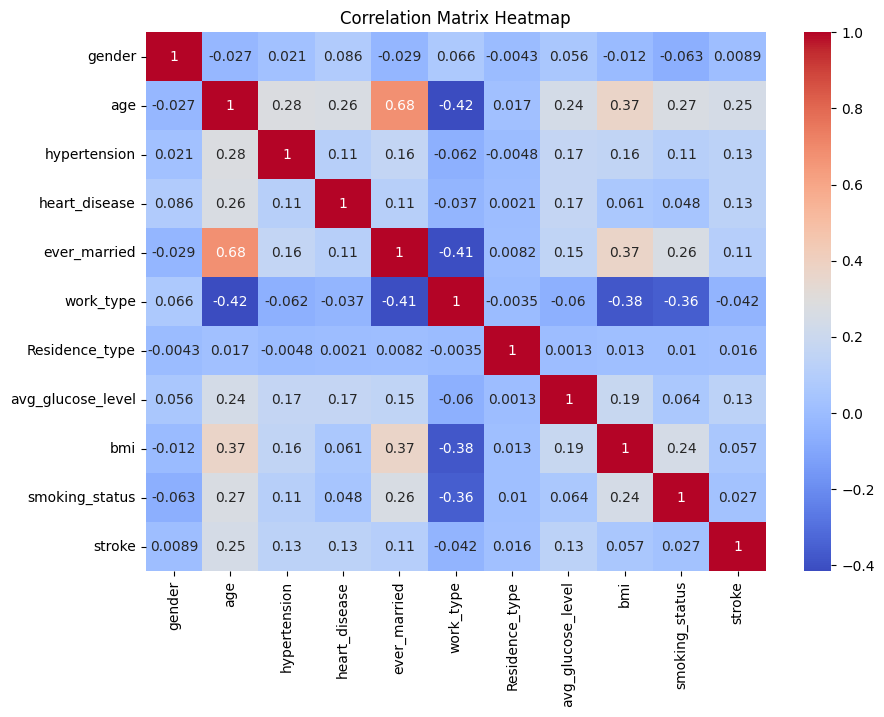

In [ ]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
# Work on models training
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr=LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9558676028084253
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       953
           1       0.00      0.00      0.00        44

    accuracy                           0.96       997
   macro avg       0.48      0.50      0.49       997
weighted avg       0.91      0.96      0.93       997



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


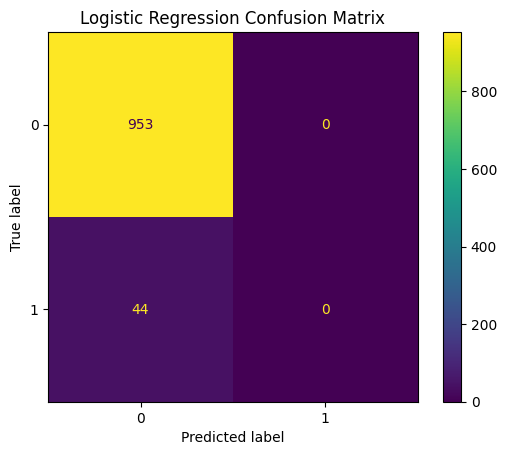

In [ ]:
#logistic regression confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix of Logistic Regression before applying hyperparameter tuning
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
#SVM
from sklearn.svm import SVC
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9558676028084253
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       953
           1       0.00      0.00      0.00        44

    accuracy                           0.96       997
   macro avg       0.48      0.50      0.49       997
weighted avg       0.91      0.96      0.93       997



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


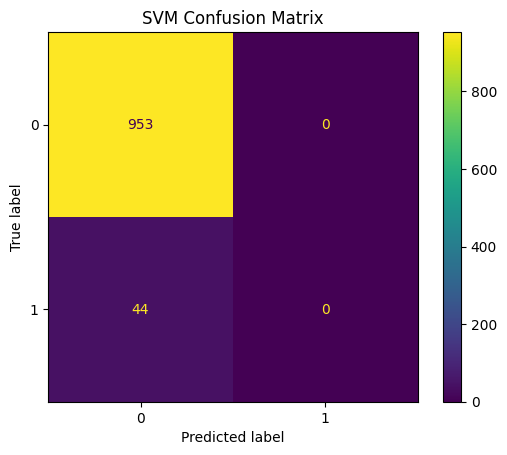

In [ ]:
#Confusion matrix of SVM before applying hyperparameter tuning
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9538615847542627
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       953
           1       0.25      0.02      0.04        44

    accuracy                           0.95       997
   macro avg       0.60      0.51      0.51       997
weighted avg       0.93      0.95      0.94       997



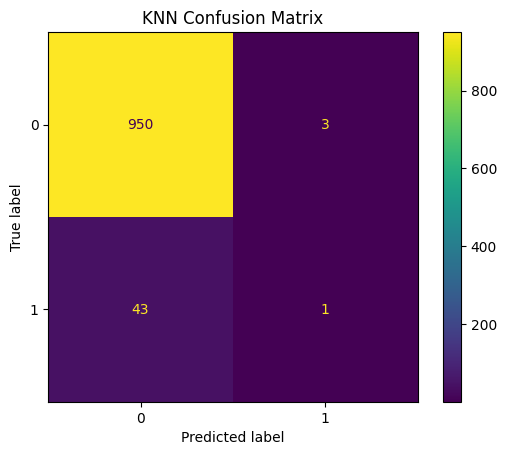

In [ ]:
#Confusion matrix of  KNN before applying hyperparameter tuning
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9558676028084253
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       953
           1       0.50      0.02      0.04        44

    accuracy                           0.96       997
   macro avg       0.73      0.51      0.51       997
weighted avg       0.94      0.96      0.94       997



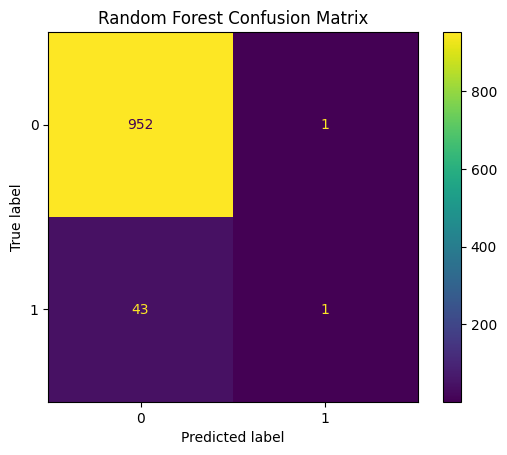

In [ ]:
#Confusion matrix of Random Forest Classifier before applying hyperparameter tuning
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

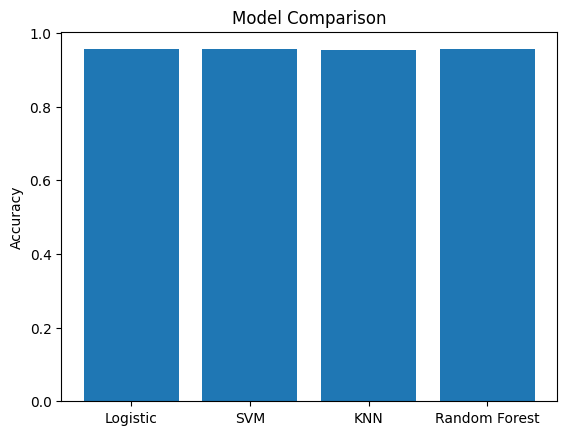

In [ ]:
# Accuracy comparasion
import matplotlib.pyplot as plt

models = ["Logistic", "SVM", "KNN", "Random Forest"]
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# ROC Curve Before Hyperparameter Tuning
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_svm = svm.predict_proba(X_test)[:,1]
y_prob_knn = knn.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)
auc_rf = auc(fpr_rf, tpr_rf)

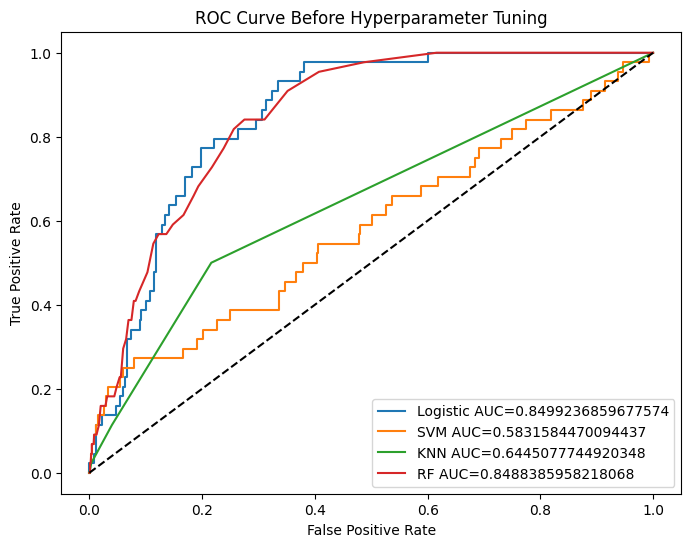

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic AUC="+str(auc_lr))
plt.plot(fpr_svm, tpr_svm, label="SVM AUC="+str(auc_svm))
plt.plot(fpr_knn, tpr_knn, label="KNN AUC="+str(auc_knn))
plt.plot(fpr_rf, tpr_rf, label="RF AUC="+str(auc_rf))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Before Hyperparameter Tuning")
plt.legend()
plt.show()

In [ ]:
# using hyper parameters for tunning
from sklearn.model_selection import GridSearchCV
# Logistic Regression
lr_grid = GridSearchCV(LogisticRegression(), {'C':[0.1,1,10]}, cv=5)
lr_grid.fit(X_train, y_train)

# SVM
svm_grid = GridSearchCV(SVC(), {'C':[0.1,1], 'kernel':['Poly','rbf']}, cv=5)
svm_grid.fit(X_train, y_train)

# KNN
knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors':[3,5,7]}, cv=5)
knn_grid.fit(X_train, y_train)

# Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(), {'n_estimators':[50,100]}, cv=5)
rf_grid.fit(X_train, y_train)

print("Best LR:", lr_grid.best_params_)
print("Best SVM:", svm_grid.best_params_)
print("Best KNN:", knn_grid.best_params_)
print("Best RF:", rf_grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

Best LR: {'C': 0.1}
Best SVM: {'C': 0.1, 'kernel': 'rbf'}
Best KNN: {'n_neighbors': 7}
Best RF: {'n_estimators': 100}


In [ ]:
best_lr = lr_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

In [ ]:
y_pred_lr = best_lr.predict(X_test)
y_pred_svm = best_svm.predict(X_test)
y_pred_knn = best_knn.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf
}

for name, pred in models.items():
    print(f"\n{name}")
    print("Best Parameters:",
          lr_grid.best_params_ if name=="Logistic Regression" else
          svm_grid.best_params_ if name=="SVM" else
          knn_grid.best_params_ if name=="KNN" else
          rf_grid.best_params_)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))


Logistic Regression
Best Parameters: {'C': 0.1}
Accuracy : 0.9558676028084253
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

SVM
Best Parameters: {'C': 0.1, 'kernel': 'rbf'}
Accuracy : 0.9558676028084253
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

KNN
Best Parameters: {'n_neighbors': 7}
Accuracy : 0.9538615847542627
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Random Forest
Best Parameters: {'n_estimators': 100}
Accuracy : 0.9558676028084253
Precision: 0.5
Recall   : 0.022727272727272728
F1 Score : 0.043478260869565216


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
svm_grid = GridSearchCV(
    SVC(probability=True),
    {'C': [0.1, 1], 'kernel': ['linear', 'rbf']},
    cv=5
)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

In [ ]:
# Logistic Regression
y_prob_lr = best_lr.predict_proba(X_test)[:,1]

# SVM
y_prob_svm = best_svm.predict_proba(X_test)[:,1]

# KNN
y_prob_knn = best_knn.predict_proba(X_test)[:,1]

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)
auc_rf = auc(fpr_rf, tpr_rf)

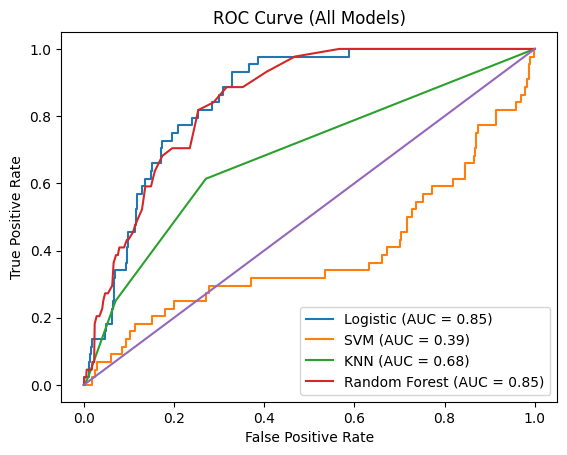

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Diagonal line
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()

plt.show()

Logistic Regression
Best Parameters: {'C': 0.1}
Accuracy : 0.9558676028084253
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Confusion Matrix:
 [[953   0]
 [ 44   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


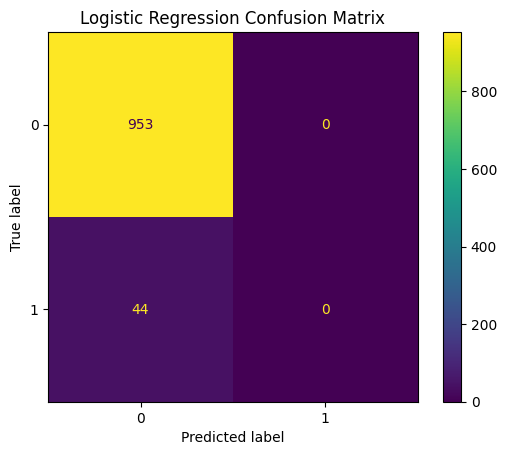

In [ ]:
best_lr = lr_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("Logistic Regression")
print("Best Parameters:", lr_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)

ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

SVM
Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy : 0.9558676028084253


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Confusion Matrix:
 [[953   0]
 [ 44   0]]


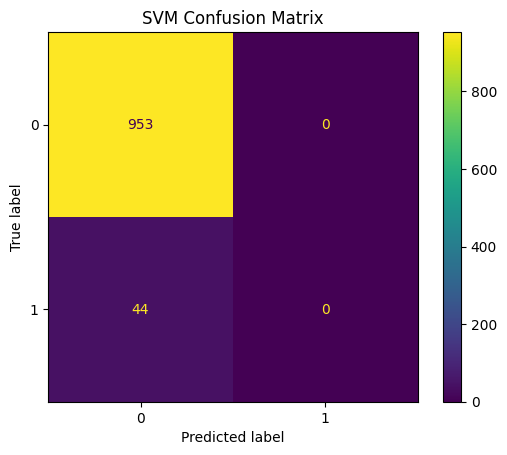

In [ ]:
best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test)

print("SVM")
print("Best Parameters:", svm_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

KNN
Best Parameters: {'n_neighbors': 7}
Accuracy : 0.9538615847542627
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Confusion Matrix:
 [[951   2]
 [ 44   0]]


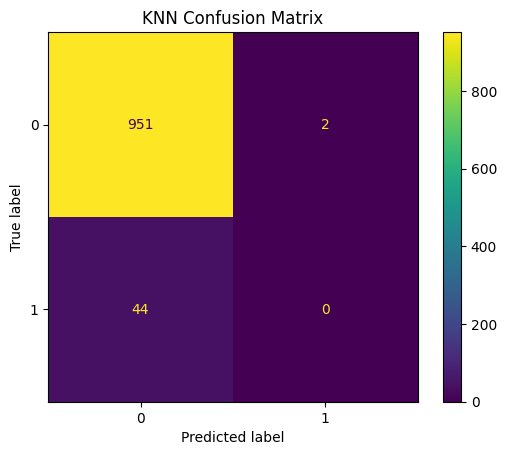

In [ ]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print("KNN")
print("Best Parameters:", knn_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm_knn)

ConfusionMatrixDisplay(cm_knn).plot()
plt.title("KNN Confusion Matrix")
plt.show()

Random Forest
Best Parameters: {'n_estimators': 100}
Accuracy : 0.9558676028084253
Precision: 0.5
Recall   : 0.022727272727272728
F1 Score : 0.043478260869565216
Confusion Matrix:
 [[952   1]
 [ 43   1]]


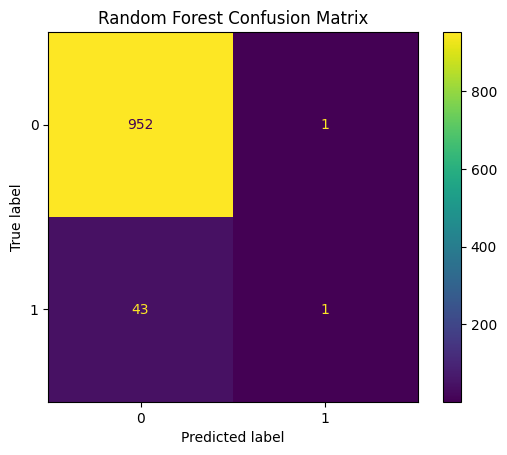

In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest")
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

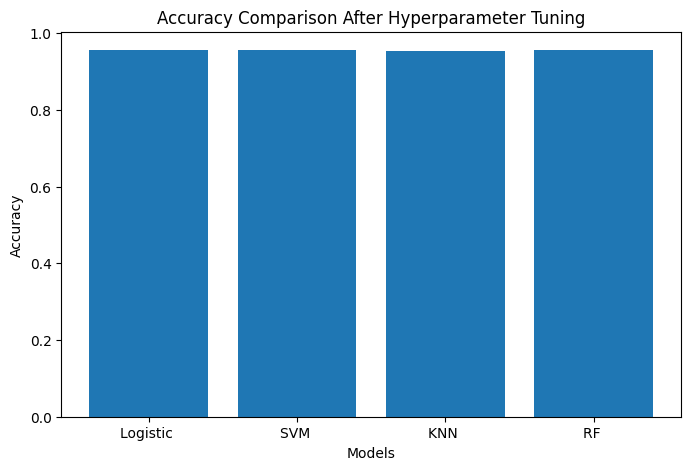

In [ ]:
#Accuracy Comparison After Hyperparameter Tuning
y_pred_lr_tuned = lr_grid.best_estimator_.predict(X_test)
y_pred_svm_tuned = svm_grid.best_estimator_.predict(X_test)
y_pred_knn_tuned = knn_grid.best_estimator_.predict(X_test)
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ["Logistic ", "SVM ", "KNN ", "RF "]

scores = [
    accuracy_score(y_test, y_pred_lr_tuned),
    accuracy_score(y_test, y_pred_svm_tuned),
    accuracy_score(y_test, y_pred_knn_tuned),
    accuracy_score(y_test, y_pred_rf_tuned)
]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.title("Accuracy Comparison After Hyperparameter Tuning")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()